In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H4分子的几何构型（线性排列，等间距）
bond_length = 1.0  # H-H键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
    ('H', (2*bond_length, 0., 0.)),
    ('H', (3*bond_length, 0., 0.))
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -2.09854594 Ha
FCI能量: -2.16638745 Ha


In [2]:
clusters = [(i, j) for i in range(4) for j in range(i+1,4 )]
clusters.extend([(i, j) for i in range(4,8) for j in range(i+1,8 )])
len(clusters)

12

In [4]:
hi = ha.hilbert
g = nk.graph.Graph(edges=clusters)
# 创建采样器
sa = nk.sampler.MetropolisFermionHop(
    hi,
    graph=g,
    n_chains=64,
    spin_symmetric=True,
    sweep_size=hi.size * 4,
    reset_chains=True
)

# 使用Slater模型确保反对称性
ma = nk.models.Jastrow(param_dtype=complex)
vs = nk.vqs.MCState(
    sa,
    ma,
    n_discard_per_chain=100,
    n_samples=2000,
    seed=42
)
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(
    diag_shift=0.01,
    holomorphic=True,
    solver=nk.optimizer.solver.cholesky
)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
jastrow_log = nk.logging.RuntimeLog()
gs.run(300, out=jastrow_log)


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=2000 (2000 per device/MPI rank) does not divide n_chains=64, increased to 2048 (2048 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 300/300 [00:26<00:00, 11.54it/s, Energy=-2.11167+0.00001j ± 0.00033 [σ²=0.00003, R̂=1.2111]]        


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [8]:
jastrow_log['Energy']['Mean']

array([ 0.10622863+1.44794209e-04j, -0.01363831-3.07493396e-04j,
       -0.21699334+2.14100457e-04j, -0.35188254+6.77262064e-04j,
       -0.53100297-6.07896696e-06j, -0.70200839+1.20204239e-04j,
       -0.91008404+6.81483922e-04j, -1.09222548-1.90610955e-04j,
       -1.19440833+4.24255206e-04j, -1.34644461-6.67792194e-04j,
       -1.49201853+2.83846613e-04j, -1.5849623 -2.79111316e-04j,
       -1.6877966 +5.69138321e-04j, -1.73389754+2.78448348e-04j,
       -1.75557413-8.64542951e-04j, -1.83545951-1.38299446e-03j,
       -1.90121739-4.60818955e-04j, -1.90613556-2.88862632e-04j,
       -1.94201146+4.49743922e-04j, -1.9529669 -2.92581829e-04j,
       -1.95899294+1.02409068e-03j, -2.00025202+3.64654878e-04j,
       -2.00497885-1.63255898e-04j, -2.01897216-9.85284080e-05j,
       -2.03567308+4.96008317e-06j, -2.04569321-8.69606229e-05j,
       -2.04842886-1.07598213e-04j, -2.05735297-1.35064465e-04j,
       -2.0727813 +1.11766987e-04j, -2.06847684-1.34648986e-04j,
       -2.07184606+3.1376

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


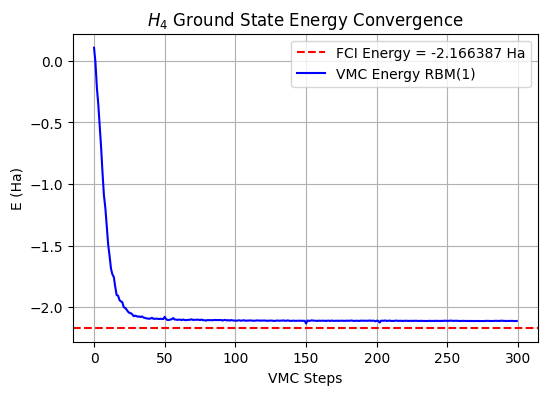


最终VMC能量: -2.11167159+0.00000932j Ha
与FCI能量误差: 0.05471585 Ha


In [9]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量
data1 = jastrow_log

x1 = data1["Energy"]["iters"]
y1 = data1["Energy"]["Mean"]
# x2 = data2["Energy"]["iters"]
# y2 = data2["Energy"]["Mean"]["real"]

# 绘制能量收敛曲线
plt.figure(figsize=(6, 4))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI Energy = {E_fci:.6f} Ha")
plt.plot(x1, y1, 'b-', label="VMC Energy RBM(1)")
# plt.plot(x2, y2, 'g-', label="VMC Energy RBM(2)")
plt.xlabel("VMC Steps")
plt.ylabel("E (Ha)")
plt.title("$H_4$ Ground State Energy Convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y1[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y1[-1] - E_fci):.8f} Ha")

In [7]:
data1['Energy'].keys()

dict_keys(['iters', 'Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'])